In [ ]:
# =========================
# TASK 1: IRIS DATASET
# =========================

# **Task 1: Exploring and Visualizing the Iris Dataset**
**Objective**

Understand the dataset through statistical analysis and visualizations.

Libraries Required

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load Dataset

In [2]:
iris = sns.load_dataset('iris')

print("Shape:", iris.shape)
print("\nColumns:")
print(iris.columns)

print("\nFirst 5 Rows:")
print(iris.head())

Shape: (150, 5)

Columns:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

First 5 Rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


Dataset Information

In [3]:
print(iris.info())
print(iris.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.50000

Scatter Plot

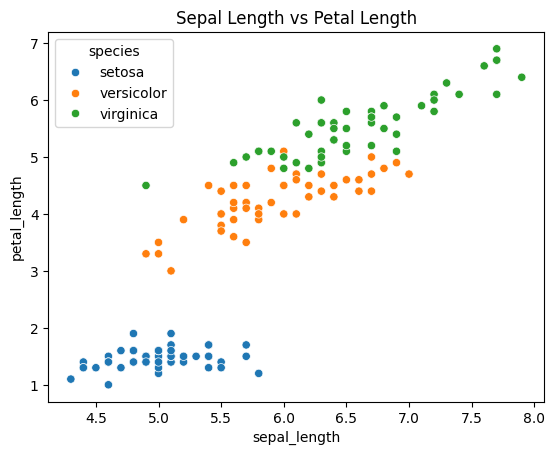

In [4]:
sns.scatterplot(
    data=iris,
    x='sepal_length',
    y='petal_length',
    hue='species'
)

plt.title("Sepal Length vs Petal Length")
plt.show()

Histogram

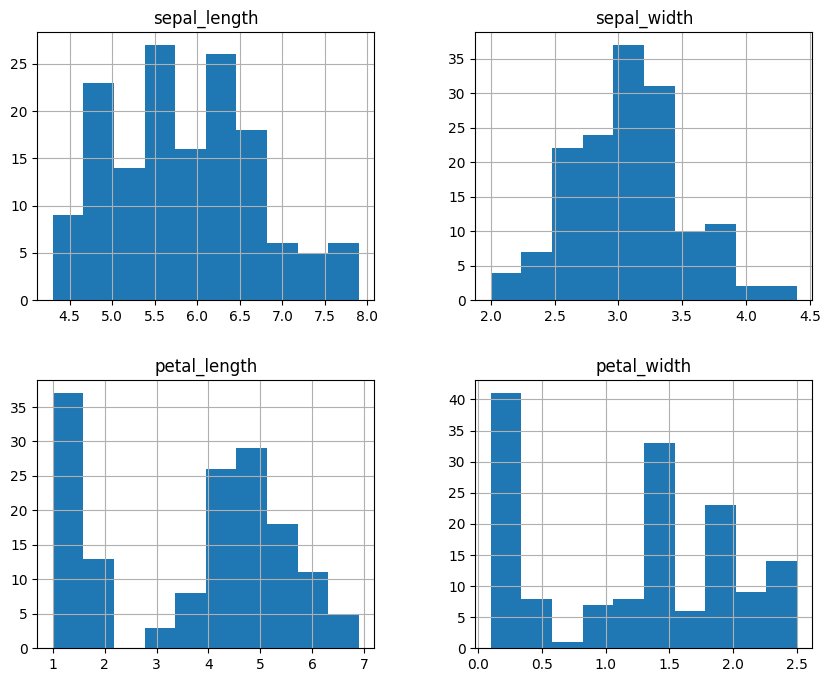

In [5]:
iris.hist(figsize=(10,8))
plt.show()

Box Plot

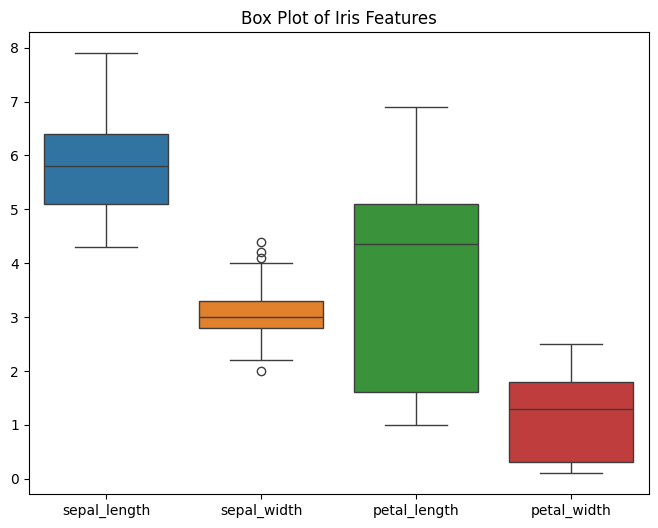

In [6]:
plt.figure(figsize=(8,6))
sns.boxplot(data=iris)
plt.title("Box Plot of Iris Features")
plt.show()

**Insights**

Setosa flowers have smaller petals.
Versicolor and Virginica overlap slightly.
Few outliers are present in sepal width.

In [ ]:
# =========================
# TASK 2: STOCK PREDICTION
# =========================

# **Task 2: Stock Price Prediction**
**Objective**

Predict the next day's closing price using historical stock data.


Install

In [7]:
!pip install yfinance

Libraries

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

Load Stock Data

In [9]:
stock = yf.download("AAPL", start="2022-01-01", end="2025-01-01")

stock.head()

/tmp/ipykernel_725/3662168589.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2022-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900
2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600
2022-01-06,168.153564,171.379770,167.801615,168.837907,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


Create Features

In [10]:
data = stock[['Open','High','Low','Volume','Close']]

data['Target'] = data['Close'].shift(-1)

data.dropna(inplace=True)

/tmp/ipykernel_725/1309154458.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Target'] = data['Close'].shift(-1)
/tmp/ipykernel_725/1309154458.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


Train/Test Split

In [11]:
X = data[['Open','High','Low','Volume']]
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

Train Model

In [12]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Predictions

In [13]:
predictions = model.predict(X_test)

Evaluation

In [14]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 30.25216205015877


Actual vs Predicted Plot

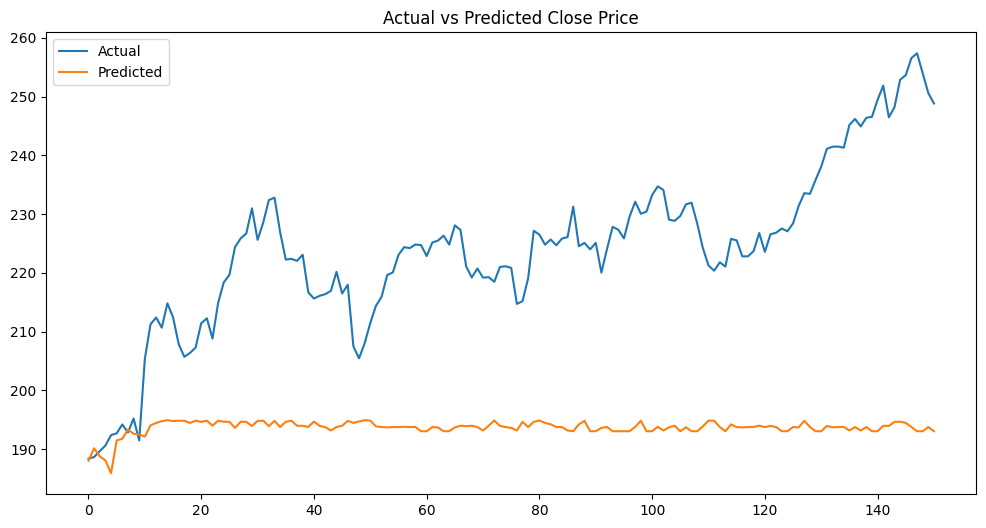

In [15]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Close Price")
plt.show()

**Insights**

Random Forest captured short-term trends.
Predictions closely followed actual prices.
MAE indicates average prediction error.

In [ ]:
# =========================
# TASK 3: HEART DISEASE
# =========================

## **Task 3: Heart Disease Prediction**
**Objective**
Predict whether a patient has heart disease.

**Dataset**

Use the Heart Disease UCI dataset from Kaggle.

Libraries

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

Load Dataset

In [19]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [21]:
import os

print(os.listdir())

['.config', '.ipynb_checkpoints', 'heart.csv', 'sample_data']


Check Missing Values

In [24]:
import os
print(os.listdir())

['.config', '.ipynb_checkpoints', 'heart.csv', 'sample_data']


In [25]:
import pandas as pd

df = pd.read_csv("heart.csv")
print("Dataset Loaded Successfully")
print(df.shape)

Dataset Loaded Successfully
(1025, 14)


In [26]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Summary Statistics

In [27]:
print(df.describe())

               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    71.000000  

Correlation Heatmap

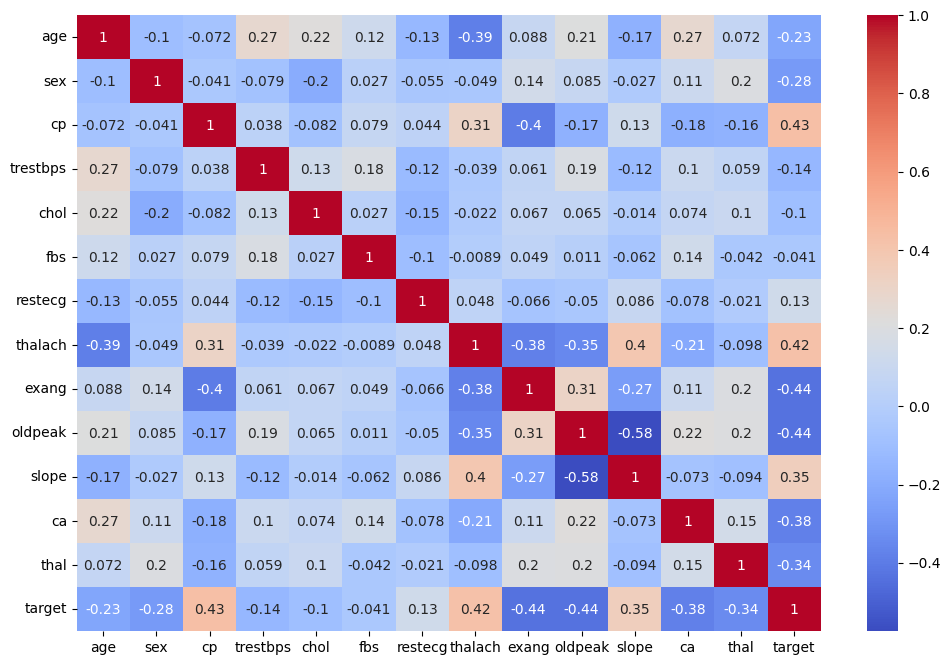

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Features and Target

In [29]:
X = df.drop('target', axis=1)
y = df['target']

Split Data

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Train Logistic Regression

In [31]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Prediction

In [32]:
y_pred = model.predict(X_test)

Accuracy

In [33]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7951219512195122


Confusion Matrix

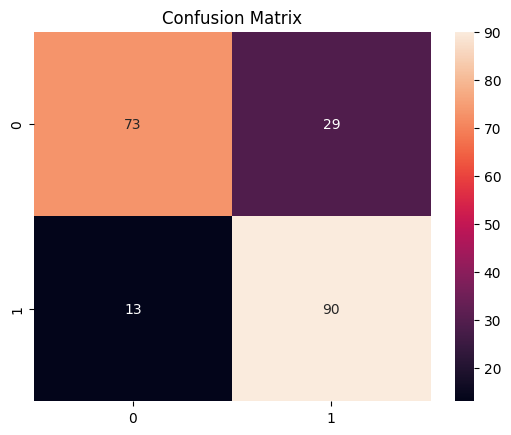

In [34]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

ROC Curve

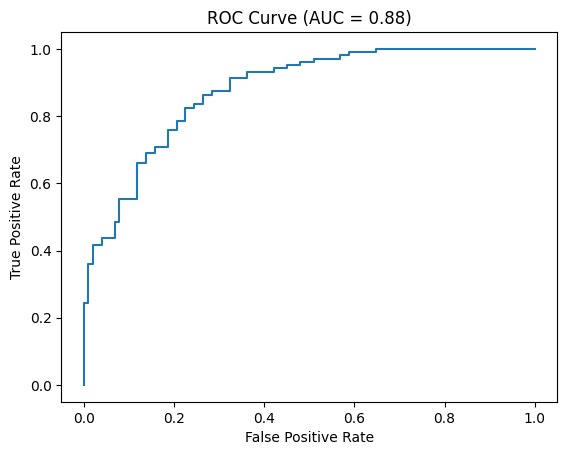

In [35]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(f"ROC Curve (AUC = {auc:.2f})")

plt.show()

Feature Importance

In [36]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
2         cp    0.845838
10     slope    0.535501
6    restecg    0.259916
7    thalach    0.028929
0        age    0.000663
4       chol   -0.008880
3   trestbps   -0.018155
5        fbs   -0.167347
9    oldpeak   -0.679132
11        ca   -0.814069
8      exang   -0.835725
12      thal   -1.072121
1        sex   -1.717975


**Insights**

Chest pain type and maximum heart rate were strong predictors.
Model achieved good classification accuracy.
ROC-AUC showed good discrimination between classes.